# 05 - Análisis de categorías y productos

Este notebook tiene como objetivo analizar la composición comercial de la base a partir de las categorías y productos disponibles.

El análisis se enfoca en responder preguntas como:

- ¿Qué categorías concentran la mayor venta neta?
- ¿Qué categorías tienen mayor número de productos?
- ¿Qué productos generan más venta?
- ¿Qué productos tienen más unidades vendidas?
- ¿Qué productos aparecen en más tickets?
- ¿Qué tan concentradas están las ventas?
- ¿Pocos productos explican gran parte de la venta?
- ¿Existen productos con ventas muy altas pero baja frecuencia?
- ¿Existen productos muy frecuentes pero de bajo valor?
- ¿Cómo cambia la composición de categorías entre PDV?
- ¿Qué productos tienen mayor dependencia de promociones?

La variable principal del análisis será `VENTA_NETA`, definida como:

`VENTA_NETA = VENTA - DESCUENTO`

In [1]:
# ===============================
# Imports principales
# ===============================

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ===============================
# Rutas del proyecto
# ===============================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

CATEGORIAS_FIGURES_DIR = FIGURES_DIR / "categorias"
PRODUCTOS_FIGURES_DIR = FIGURES_DIR / "productos"

PROCESSED_FILE = PROCESSED_DIR / "ventas_eda.parquet"

CATEGORIAS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PRODUCTOS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:")
print(PROJECT_ROOT)

print("\nArchivo procesado:")
print(PROCESSED_FILE)

print("\n¿Existe el archivo?")
print(PROCESSED_FILE.exists())

Raíz del proyecto:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica

Archivo procesado:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\ventas_eda.parquet

¿Existe el archivo?
True


In [3]:
# ===============================
# Carga de base limpia
# ===============================

df = pd.read_parquet(PROCESSED_FILE)

df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")

print("Base procesada cargada correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Base procesada cargada correctamente.
Filas: 409,760
Columnas: 54


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM,FECHA_ORIGINAL,OFERTA_ID_NUM,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_BRUTO,PRECIO_UNITARIO_NETO,PROMO_OFERTA_FLAG,PROMO_DESCUENTO_FLAG,PROMO_FLAG,TIPO_PROMO,ANIO,MES,DIA,DIA_SEMANA_NUM,DIA_SEMANA,SEMANA_ANIO,TRIMESTRE,FIN_SEMANA,FIN_MES,INICIO_MES,QUINCENA,MES_NOMBRE,DIA_SEMANA_NOMBRE,TICKET_ID,FLAG_FECHA_NULA,FLAG_CANT_NULA,FLAG_CANT_CERO,FLAG_CANT_NEGATIVA,FLAG_VENTA_NULA,FLAG_VENTA_CERO,FLAG_VENTA_NEGATIVA,FLAG_DESCUENTO_NULO,FLAG_DESCUENTO_CERO,FLAG_DESCUENTO_NEGATIVO,FLAG_DESCUENTO_MAYOR_VENTA,FLAG_VENTA_NETA_NULA,FLAG_VENTA_NETA_CERO,FLAG_VENTA_NETA_NEGATIVA,FLAG_PRECIO_UNITARIO_NETO_NULO,FLAG_PRECIO_UNITARIO_NETO_NEGATIVO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
0,4,2023-01-01,980,4,0,1,04010,1280454,3.00,298.00,0.00,10,44927,0,298.00,0.00,99.33,99.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
1,12,2023-01-01,1255,4,0,2,04010,1328730,1.00,115.00,0.00,10,44927,0,115.00,0.00,115.00,115.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_2,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
2,24,2023-01-01,1255,4,0,3,04010,1036266,3.00,448.00,0.00,10,44927,0,448.00,0.00,149.33,149.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,36,2023-01-01,1311,6,0,4,08061,1265857,1.00,82.00,0.00,11,44927,0,82.00,0.00,82.00,82.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1311_4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
4,37,2023-01-01,980,4,0,5,04010,1328946,4.00,519.00,0.00,10,44927,0,519.00,0.00,129.75,129.75,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_5,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True


In [4]:
# ===============================
# Validación de columnas necesarias
# ===============================

columnas_necesarias = [
    "FECHA",
    "ANIO",
    "MES",
    "PDV",
    "Estrato",
    "CATEG",
    "GRUCOM",
    "PLU_SAP",
    "TICKET_ID",
    "CANT",
    "VENTA",
    "DESCUENTO",
    "VENTA_NETA",
    "PROMO_FLAG",
    "TIPO_PROMO",
    "REGISTRO_ESPECIAL",
    "REGISTRO_VALIDO_BASICO"
]

faltantes = [col for col in columnas_necesarias if col not in df.columns]

if len(faltantes) == 0:
    print("Todas las columnas necesarias están disponibles.")
else:
    print("Faltan estas columnas:")
    print(faltantes)

Todas las columnas necesarias están disponibles.


In [5]:
# ===============================
# Resumen general por categoría
# ===============================

resumen_categorias = (
    df.groupby(["GRUCOM", "CATEG"])
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        pdv=("PDV", "nunique"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        lineas_promo=("PROMO_FLAG", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum"),
        registros_validos_basicos=("REGISTRO_VALIDO_BASICO", "sum")
    )
    .reset_index()
)

resumen_categorias["participacion_venta_neta_pct"] = (
    resumen_categorias["venta_neta"] / resumen_categorias["venta_neta"].sum() * 100
)

resumen_categorias["participacion_unidades_pct"] = (
    resumen_categorias["unidades"] / resumen_categorias["unidades"].sum() * 100
)

resumen_categorias["ticket_promedio_neto"] = np.where(
    resumen_categorias["tickets"] > 0,
    resumen_categorias["venta_neta"] / resumen_categorias["tickets"],
    np.nan
)

resumen_categorias["venta_neta_por_producto"] = np.where(
    resumen_categorias["productos"] > 0,
    resumen_categorias["venta_neta"] / resumen_categorias["productos"],
    np.nan
)

resumen_categorias["descuento_pct"] = np.where(
    resumen_categorias["venta_bruta"] > 0,
    resumen_categorias["descuento"] / resumen_categorias["venta_bruta"] * 100,
    np.nan
)

resumen_categorias["promo_pct_lineas"] = np.where(
    resumen_categorias["filas"] > 0,
    resumen_categorias["lineas_promo"] / resumen_categorias["filas"] * 100,
    np.nan
)

resumen_categorias["registros_especiales_pct"] = np.where(
    resumen_categorias["filas"] > 0,
    resumen_categorias["registros_especiales"] / resumen_categorias["filas"] * 100,
    np.nan
)

resumen_categorias = resumen_categorias.sort_values("venta_neta", ascending=False)

resumen_categorias

,GRUCOM,CATEG,filas,dias,pdv,tickets,productos,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_unidades_pct,ticket_promedio_neto,venta_neta_por_producto,descuento_pct,promo_pct_lineas,registros_especiales_pct
0,10,04010,158659,731,3,121604,1173,"61,096,386.00","7,317,028.00","53,779,358.00","244,163.00",32262,9111,151519,43.65,49.33,442.25,"45,847.71",11.98,20.33,5.74
3,11,08042,52788,731,3,41127,1748,"29,985,976.00","2,868,994.00","27,116,982.00","60,593.26",16647,902,52005,22.01,12.24,659.35,"15,513.15",9.57,31.54,1.71
2,11,08029,132505,731,3,95594,1391,"29,011,472.00","3,044,652.00","25,966,820.00","123,061.92",40592,2167,130491,21.08,24.86,271.64,"18,667.74",10.49,30.63,1.64
4,11,08061,53538,731,3,42098,804,"10,970,778.00","816,908.00","10,153,870.00","54,349.08",13414,741,52806,8.24,10.98,241.20,"12,629.19",7.45,25.06,1.38
5,11,08062,10997,723,3,8608,666,"7,667,928.00","2,222,411.00","5,445,517.00","10,972.18",6321,528,10491,4.42,2.22,632.61,"8,176.45",28.98,57.48,4.80
6,11,08067,876,304,2,355,255,"698,356.00",143.00,"698,213.00","1,373.79",3,47,829,0.57,0.28,"1,966.80","2,738.09",0.02,0.34,5.37
1,10,04019,397,288,3,392,2,"31,602.00",0.00,"31,602.00",460.00,0,1,396,0.03,0.09,80.62,"15,801.00",0.00,0.00,0.25


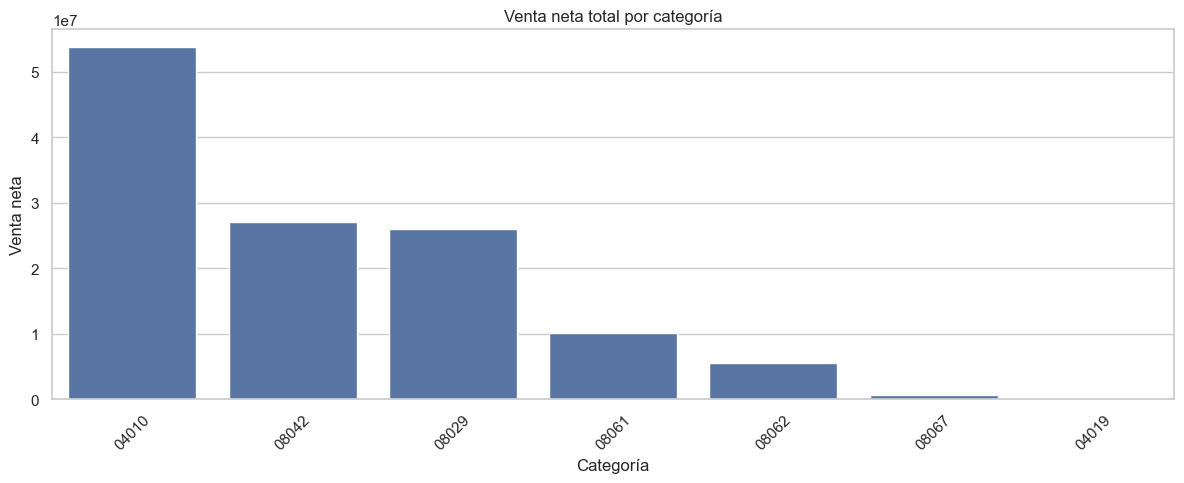

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\categorias\venta_neta_por_categoria.png


In [6]:
# ===============================
# Venta neta por categoría
# ===============================

plt.figure(figsize=(12, 5))

sns.barplot(
    data=resumen_categorias,
    x="CATEG",
    y="venta_neta",
    order=resumen_categorias["CATEG"]
)

plt.title("Venta neta total por categoría")
plt.xlabel("Categoría")
plt.ylabel("Venta neta")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = CATEGORIAS_FIGURES_DIR / "venta_neta_por_categoria.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

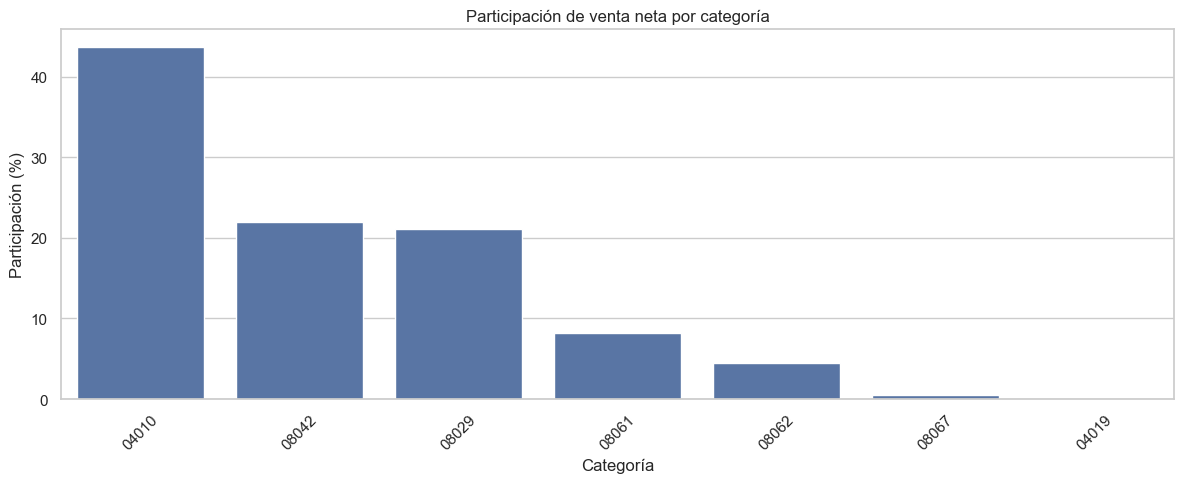

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\categorias\participacion_venta_neta_categoria.png


In [7]:
# ===============================
# Participación de venta neta por categoría
# ===============================

plt.figure(figsize=(12, 5))

sns.barplot(
    data=resumen_categorias,
    x="CATEG",
    y="participacion_venta_neta_pct",
    order=resumen_categorias["CATEG"]
)

plt.title("Participación de venta neta por categoría")
plt.xlabel("Categoría")
plt.ylabel("Participación (%)")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = CATEGORIAS_FIGURES_DIR / "participacion_venta_neta_categoria.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

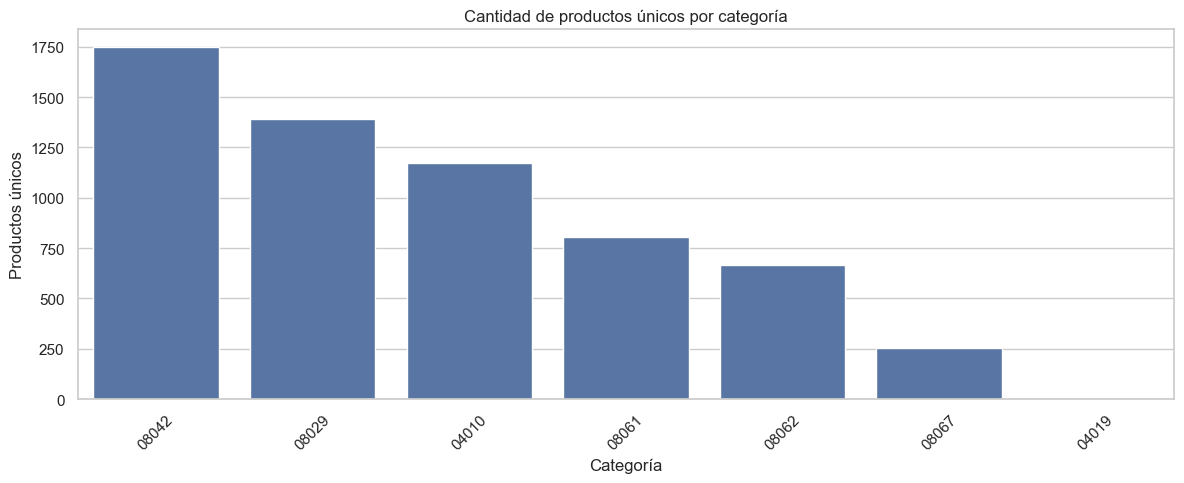

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\categorias\productos_unicos_por_categoria.png


In [8]:
# ===============================
# Productos únicos por categoría
# ===============================

plt.figure(figsize=(12, 5))

sns.barplot(
    data=resumen_categorias.sort_values("productos", ascending=False),
    x="CATEG",
    y="productos"
)

plt.title("Cantidad de productos únicos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Productos únicos")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = CATEGORIAS_FIGURES_DIR / "productos_unicos_por_categoria.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

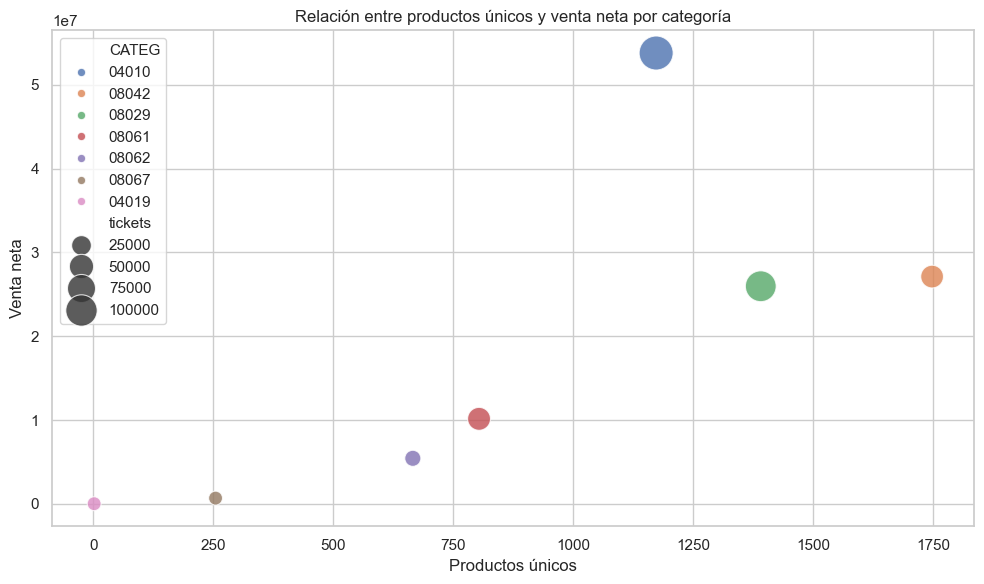

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\categorias\venta_neta_vs_productos_categoria.png


In [9]:
# ===============================
# Relación venta neta vs productos por categoría
# ===============================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=resumen_categorias,
    x="productos",
    y="venta_neta",
    size="tickets",
    hue="CATEG",
    sizes=(100, 600),
    alpha=0.8
)

plt.title("Relación entre productos únicos y venta neta por categoría")
plt.xlabel("Productos únicos")
plt.ylabel("Venta neta")
plt.tight_layout()

output_fig = CATEGORIAS_FIGURES_DIR / "venta_neta_vs_productos_categoria.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [10]:
# ===============================
# Resumen general por producto
# ===============================

resumen_productos = (
    df.groupby("PLU_SAP")
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        pdv=("PDV", "nunique"),
        categorias=("CATEG", "nunique"),
        categoria_principal=("CATEG", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        grupo_principal=("GRUCOM", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        tickets=("TICKET_ID", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        lineas_promo=("PROMO_FLAG", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum"),
        registros_validos_basicos=("REGISTRO_VALIDO_BASICO", "sum")
    )
    .reset_index()
)

resumen_productos["participacion_venta_neta_pct"] = (
    resumen_productos["venta_neta"] / resumen_productos["venta_neta"].sum() * 100
)

resumen_productos["participacion_unidades_pct"] = (
    resumen_productos["unidades"] / resumen_productos["unidades"].sum() * 100
)

resumen_productos["ticket_promedio_producto"] = np.where(
    resumen_productos["tickets"] > 0,
    resumen_productos["venta_neta"] / resumen_productos["tickets"],
    np.nan
)

resumen_productos["unidades_por_ticket"] = np.where(
    resumen_productos["tickets"] > 0,
    resumen_productos["unidades"] / resumen_productos["tickets"],
    np.nan
)

resumen_productos["precio_unitario_neto_promedio"] = np.where(
    resumen_productos["unidades"] > 0,
    resumen_productos["venta_neta"] / resumen_productos["unidades"],
    np.nan
)

resumen_productos["descuento_pct"] = np.where(
    resumen_productos["venta_bruta"] > 0,
    resumen_productos["descuento"] / resumen_productos["venta_bruta"] * 100,
    np.nan
)

resumen_productos["promo_pct_lineas"] = np.where(
    resumen_productos["filas"] > 0,
    resumen_productos["lineas_promo"] / resumen_productos["filas"] * 100,
    np.nan
)

resumen_productos["registros_especiales_pct"] = np.where(
    resumen_productos["filas"] > 0,
    resumen_productos["registros_especiales"] / resumen_productos["filas"] * 100,
    np.nan
)

resumen_productos = resumen_productos.sort_values("venta_neta", ascending=False)

resumen_productos.head(20)

,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,grupo_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_unidades_pct,ticket_promedio_producto,unidades_por_ticket,precio_unitario_neto_promedio,descuento_pct,promo_pct_lineas,registros_especiales_pct
1513,1036246,7872,719,3,1,04010,10,7675,"2,007,463.00","48,506.00","1,958,957.00","10,799.00",812,143,7754,1.59,2.18,255.24,1.41,181.40,2.42,10.32,1.82
1518,1036266,4699,697,3,1,04010,10,4397,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",901,146,4571,1.32,2.90,370.22,3.27,113.25,15.84,19.17,3.11
4657,1331944,2142,569,3,1,04010,10,2117,"1,380,941.00","11,793.00","1,369,148.00","3,143.00",96,5,2137,1.11,0.63,646.74,1.48,435.62,0.85,4.48,0.23
4936,1338873,8419,701,3,1,04010,10,8064,"1,338,612.00","26,871.00","1,311,741.00","13,508.00",1279,33,8387,1.06,2.73,162.67,1.68,97.11,2.01,15.19,0.39
3166,1246431,842,79,3,1,08029,11,627,"1,603,593.00","340,519.00","1,263,074.00","1,606.00",613,133,709,1.03,0.32,"2,014.47",2.56,786.47,21.23,72.80,15.80
1515,1036252,5075,708,3,1,04010,10,4735,"1,314,831.00","89,242.00","1,225,589.00","8,419.00",925,207,4886,0.99,1.70,258.84,1.78,145.57,6.79,18.23,4.08
1516,1036253,2824,633,3,1,04010,10,2682,"1,665,321.00","457,305.00","1,208,016.00","14,342.00",601,194,2720,0.98,2.90,450.42,5.35,84.23,27.46,21.28,6.87
4155,1313279,4665,695,3,1,04010,10,4299,"1,145,699.00","62,929.00","1,082,770.00","6,971.00",980,126,4545,0.88,1.41,251.87,1.62,155.32,5.49,21.01,2.70
1324,1023807,663,345,3,1,04010,10,615,"1,113,652.00","118,599.00","995,053.00",771.00,243,20,646,0.81,0.16,"1,617.97",1.25,"1,290.60",10.65,36.65,3.02
1556,1041245,803,410,3,1,04010,10,793,"980,909.00","85,998.00","894,911.00","2,724.00",69,11,792,0.73,0.55,"1,128.51",3.44,328.53,8.77,8.59,1.37


In [11]:
# ===============================
# Top 20 productos por venta neta
# ===============================

top_productos_venta = resumen_productos.head(20).copy()

top_productos_venta

,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,grupo_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_unidades_pct,ticket_promedio_producto,unidades_por_ticket,precio_unitario_neto_promedio,descuento_pct,promo_pct_lineas,registros_especiales_pct
1513,1036246,7872,719,3,1,04010,10,7675,"2,007,463.00","48,506.00","1,958,957.00","10,799.00",812,143,7754,1.59,2.18,255.24,1.41,181.40,2.42,10.32,1.82
1518,1036266,4699,697,3,1,04010,10,4397,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",901,146,4571,1.32,2.90,370.22,3.27,113.25,15.84,19.17,3.11
4657,1331944,2142,569,3,1,04010,10,2117,"1,380,941.00","11,793.00","1,369,148.00","3,143.00",96,5,2137,1.11,0.63,646.74,1.48,435.62,0.85,4.48,0.23
4936,1338873,8419,701,3,1,04010,10,8064,"1,338,612.00","26,871.00","1,311,741.00","13,508.00",1279,33,8387,1.06,2.73,162.67,1.68,97.11,2.01,15.19,0.39
3166,1246431,842,79,3,1,08029,11,627,"1,603,593.00","340,519.00","1,263,074.00","1,606.00",613,133,709,1.03,0.32,"2,014.47",2.56,786.47,21.23,72.80,15.80
1515,1036252,5075,708,3,1,04010,10,4735,"1,314,831.00","89,242.00","1,225,589.00","8,419.00",925,207,4886,0.99,1.70,258.84,1.78,145.57,6.79,18.23,4.08
1516,1036253,2824,633,3,1,04010,10,2682,"1,665,321.00","457,305.00","1,208,016.00","14,342.00",601,194,2720,0.98,2.90,450.42,5.35,84.23,27.46,21.28,6.87
4155,1313279,4665,695,3,1,04010,10,4299,"1,145,699.00","62,929.00","1,082,770.00","6,971.00",980,126,4545,0.88,1.41,251.87,1.62,155.32,5.49,21.01,2.70
1324,1023807,663,345,3,1,04010,10,615,"1,113,652.00","118,599.00","995,053.00",771.00,243,20,646,0.81,0.16,"1,617.97",1.25,"1,290.60",10.65,36.65,3.02
1556,1041245,803,410,3,1,04010,10,793,"980,909.00","85,998.00","894,911.00","2,724.00",69,11,792,0.73,0.55,"1,128.51",3.44,328.53,8.77,8.59,1.37


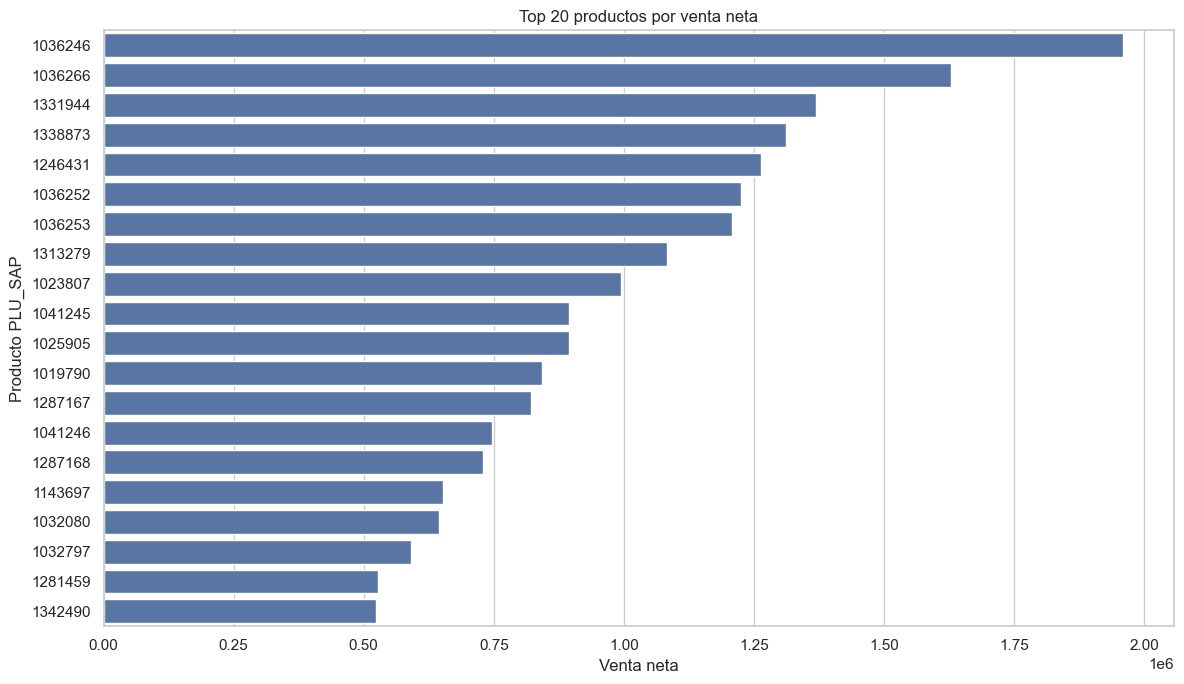

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\productos\top_20_productos_venta_neta.png


In [12]:
# ===============================
# Gráfico top productos por venta neta
# ===============================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_productos_venta,
    y="PLU_SAP",
    x="venta_neta"
)

plt.title("Top 20 productos por venta neta")
plt.xlabel("Venta neta")
plt.ylabel("Producto PLU_SAP")
plt.tight_layout()

output_fig = PRODUCTOS_FIGURES_DIR / "top_20_productos_venta_neta.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [13]:
# ===============================
# Top 20 productos por unidades vendidas
# ===============================

top_productos_unidades = (
    resumen_productos
    .sort_values("unidades", ascending=False)
    .head(20)
    .copy()
)

top_productos_unidades

,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,grupo_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_unidades_pct,ticket_promedio_producto,unidades_por_ticket,precio_unitario_neto_promedio,descuento_pct,promo_pct_lineas,registros_especiales_pct
1518,1036266,4699,697,3,1,04010,10,4397,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",901,146,4571,1.32,2.90,370.22,3.27,113.25,15.84,19.17,3.11
1516,1036253,2824,633,3,1,04010,10,2682,"1,665,321.00","457,305.00","1,208,016.00","14,342.00",601,194,2720,0.98,2.90,450.42,5.35,84.23,27.46,21.28,6.87
4936,1338873,8419,701,3,1,04010,10,8064,"1,338,612.00","26,871.00","1,311,741.00","13,508.00",1279,33,8387,1.06,2.73,162.67,1.68,97.11,2.01,15.19,0.39
1513,1036246,7872,719,3,1,04010,10,7675,"2,007,463.00","48,506.00","1,958,957.00","10,799.00",812,143,7754,1.59,2.18,255.24,1.41,181.40,2.42,10.32,1.82
1515,1036252,5075,708,3,1,04010,10,4735,"1,314,831.00","89,242.00","1,225,589.00","8,419.00",925,207,4886,0.99,1.70,258.84,1.78,145.57,6.79,18.23,4.08
4155,1313279,4665,695,3,1,04010,10,4299,"1,145,699.00","62,929.00","1,082,770.00","6,971.00",980,126,4545,0.88,1.41,251.87,1.62,155.32,5.49,21.01,2.70
4631,1331488,2372,582,3,1,04010,10,2243,"548,982.00","48,956.00","500,026.00","4,151.00",263,57,2321,0.41,0.84,222.93,1.85,120.46,8.92,11.09,2.40
1557,1041246,1713,624,3,1,04010,10,1704,"813,380.00","66,884.00","746,496.00","3,995.00",66,13,1700,0.61,0.81,438.08,2.34,186.86,8.22,3.85,0.76
3674,1281570,2719,671,3,1,08029,11,2529,"292,731.00","12,453.00","280,278.00","3,721.00",592,30,2689,0.23,0.75,110.83,1.47,75.32,4.25,21.77,1.10
1519,1036267,1736,618,2,1,04010,10,1736,"95,988.00",0.00,"95,988.00","3,574.00",0,31,1705,0.08,0.72,55.29,2.06,26.86,0.00,0.00,1.79


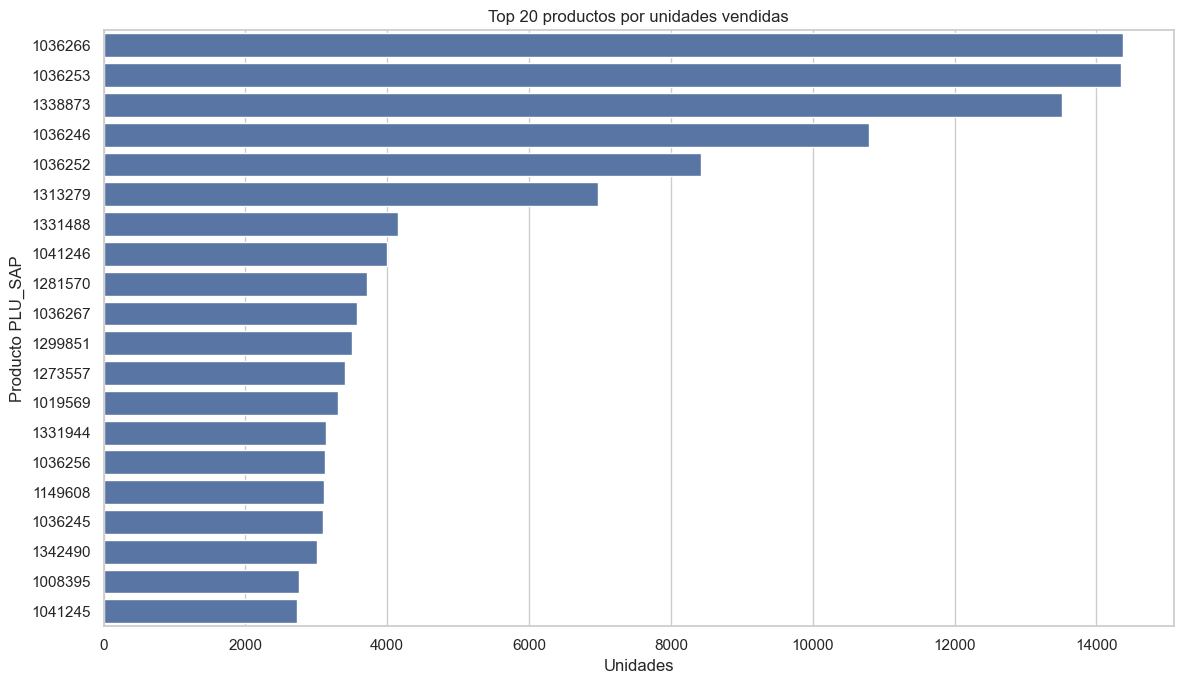

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\productos\top_20_productos_unidades.png


In [14]:
# ===============================
# Gráfico top productos por unidades
# ===============================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_productos_unidades,
    y="PLU_SAP",
    x="unidades"
)

plt.title("Top 20 productos por unidades vendidas")
plt.xlabel("Unidades")
plt.ylabel("Producto PLU_SAP")
plt.tight_layout()

output_fig = PRODUCTOS_FIGURES_DIR / "top_20_productos_unidades.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [15]:
# ===============================
# Top 20 productos por presencia en tickets
# ===============================

top_productos_tickets = (
    resumen_productos
    .sort_values("tickets", ascending=False)
    .head(20)
    .copy()
)

top_productos_tickets

,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,grupo_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_unidades_pct,ticket_promedio_producto,unidades_por_ticket,precio_unitario_neto_promedio,descuento_pct,promo_pct_lineas,registros_especiales_pct
4936,1338873,8419,701,3,1,04010,10,8064,"1,338,612.00","26,871.00","1,311,741.00","13,508.00",1279,33,8387,1.06,2.73,162.67,1.68,97.11,2.01,15.19,0.39
1513,1036246,7872,719,3,1,04010,10,7675,"2,007,463.00","48,506.00","1,958,957.00","10,799.00",812,143,7754,1.59,2.18,255.24,1.41,181.40,2.42,10.32,1.82
1515,1036252,5075,708,3,1,04010,10,4735,"1,314,831.00","89,242.00","1,225,589.00","8,419.00",925,207,4886,0.99,1.70,258.84,1.78,145.57,6.79,18.23,4.08
1518,1036266,4699,697,3,1,04010,10,4397,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",901,146,4571,1.32,2.90,370.22,3.27,113.25,15.84,19.17,3.11
4155,1313279,4665,695,3,1,04010,10,4299,"1,145,699.00","62,929.00","1,082,770.00","6,971.00",980,126,4545,0.88,1.41,251.87,1.62,155.32,5.49,21.01,2.70
1179,1019569,2950,697,3,1,08061,11,2835,"115,929.00","4,494.00","111,435.00","3,300.00",562,20,2930,0.09,0.67,39.31,1.16,33.77,3.88,19.05,0.68
1516,1036253,2824,633,3,1,04010,10,2682,"1,665,321.00","457,305.00","1,208,016.00","14,342.00",601,194,2720,0.98,2.90,450.42,5.35,84.23,27.46,21.28,6.87
3674,1281570,2719,671,3,1,08029,11,2529,"292,731.00","12,453.00","280,278.00","3,721.00",592,30,2689,0.23,0.75,110.83,1.47,75.32,4.25,21.77,1.10
3994,1299851,2593,644,3,1,08029,11,2430,"281,449.00","10,803.00","270,646.00","3,507.00",535,39,2555,0.22,0.71,111.38,1.44,77.17,3.84,20.63,1.50
3580,1273557,2415,599,3,1,04010,10,2266,"492,365.00","18,738.00","473,627.00","3,402.00",329,46,2369,0.38,0.69,209.01,1.50,139.22,3.81,13.62,1.90


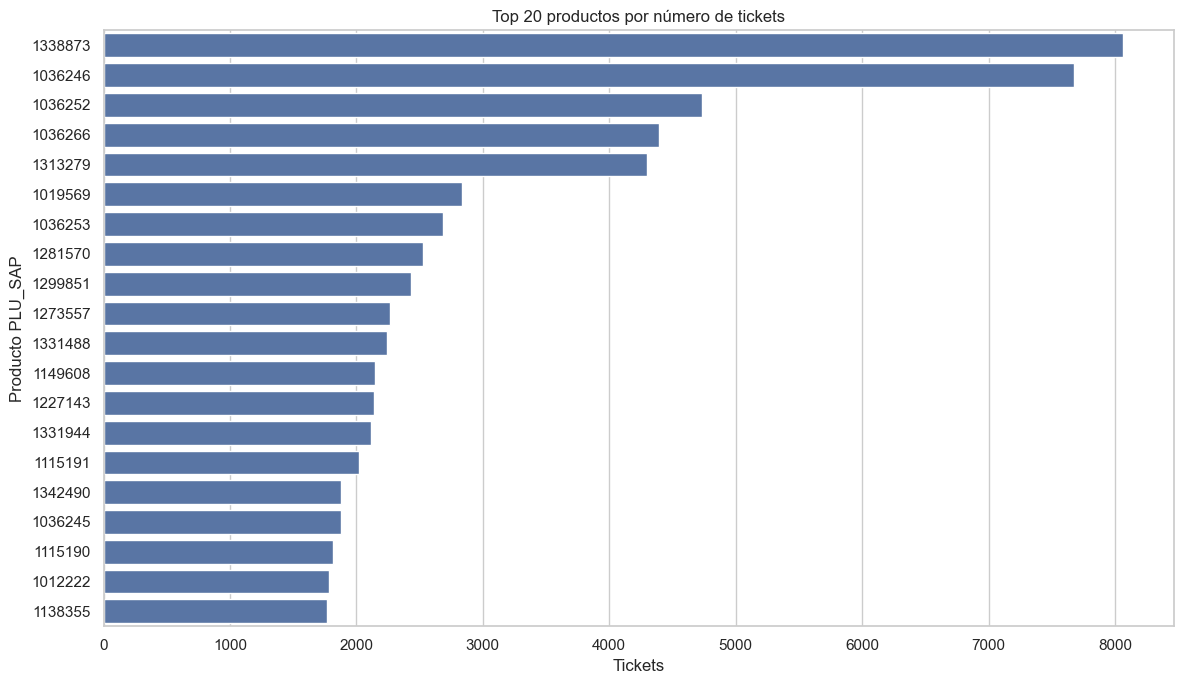

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\productos\top_20_productos_tickets.png


In [16]:
# ===============================
# Gráfico top productos por tickets
# ===============================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_productos_tickets,
    y="PLU_SAP",
    x="tickets"
)

plt.title("Top 20 productos por número de tickets")
plt.xlabel("Tickets")
plt.ylabel("Producto PLU_SAP")
plt.tight_layout()

output_fig = PRODUCTOS_FIGURES_DIR / "top_20_productos_tickets.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [17]:
# ===============================
# Top 20 productos por descuento acumulado
# ===============================

top_productos_descuento = (
    resumen_productos
    .sort_values("descuento", ascending=False)
    .head(20)
    .copy()
)

top_productos_descuento

,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,grupo_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_unidades_pct,ticket_promedio_producto,unidades_por_ticket,precio_unitario_neto_promedio,descuento_pct,promo_pct_lineas,registros_especiales_pct
1516,1036253,2824,633,3,1,04010,10,2682,"1,665,321.00","457,305.00","1,208,016.00","14,342.00",601,194,2720,0.98,2.90,450.42,5.35,84.23,27.46,21.28,6.87
3821,1289541,731,330,3,1,04010,10,601,"423,821.00","369,447.00","54,374.00",832.00,580,469,598,0.04,0.17,90.47,1.38,65.35,87.17,79.34,64.16
3166,1246431,842,79,3,1,08029,11,627,"1,603,593.00","340,519.00","1,263,074.00","1,606.00",613,133,709,1.03,0.32,"2,014.47",2.56,786.47,21.23,72.80,15.80
1518,1036266,4699,697,3,1,04010,10,4397,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",901,146,4571,1.32,2.90,370.22,3.27,113.25,15.84,19.17,3.11
3667,1281459,362,37,3,1,08029,11,257,"675,672.00","148,945.00","526,727.00",698.00,253,60,303,0.43,0.14,"2,049.52",2.72,754.62,22.04,69.89,16.57
1324,1023807,663,345,3,1,04010,10,615,"1,113,652.00","118,599.00","995,053.00",771.00,243,20,646,0.81,0.16,"1,617.97",1.25,"1,290.60",10.65,36.65,3.02
5637,1366409,339,83,3,1,08029,11,269,"545,827.00","110,167.00","435,660.00",482.00,226,45,294,0.35,0.10,"1,619.55",1.79,903.86,20.18,66.67,13.27
1367,1025905,681,349,3,1,04010,10,618,"991,230.00","97,268.00","893,962.00",768.00,230,33,660,0.73,0.16,"1,446.54",1.24,"1,164.01",9.81,33.77,4.85
5636,1366408,239,53,3,1,08029,11,176,"421,677.00","90,188.00","331,489.00",391.00,158,47,192,0.27,0.08,"1,883.46",2.22,847.80,21.39,66.11,19.67
1515,1036252,5075,708,3,1,04010,10,4735,"1,314,831.00","89,242.00","1,225,589.00","8,419.00",925,207,4886,0.99,1.70,258.84,1.78,145.57,6.79,18.23,4.08


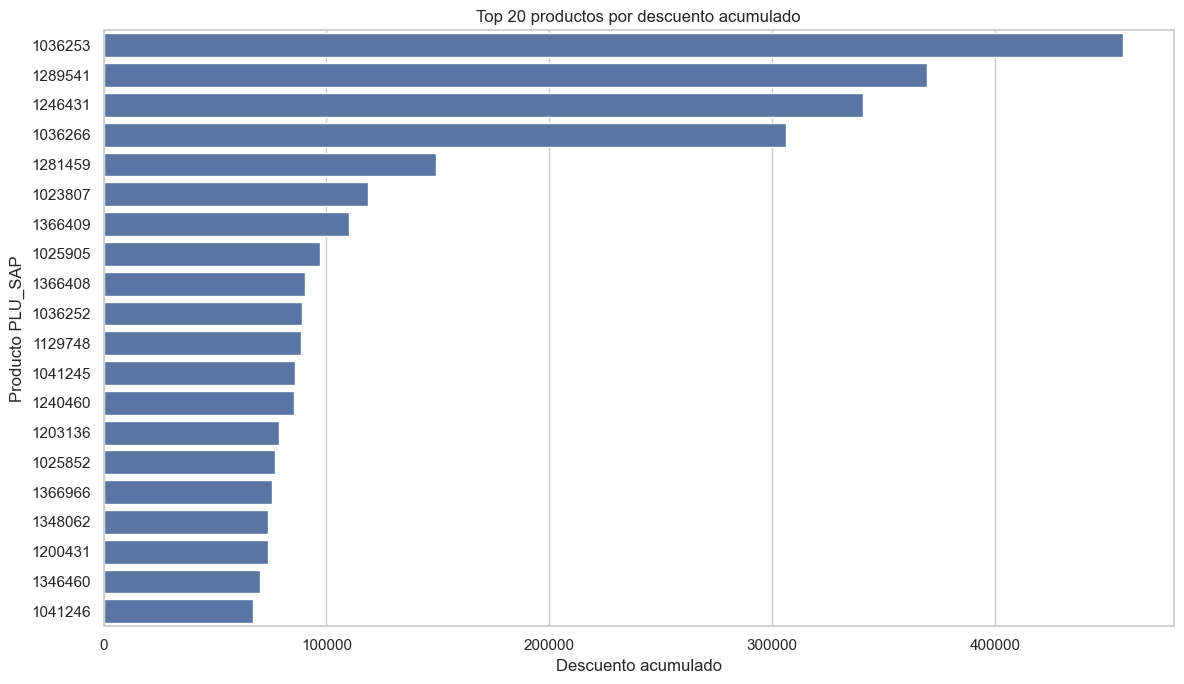

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\productos\top_20_productos_descuento.png


In [18]:
# ===============================
# Gráfico productos con mayor descuento acumulado
# ===============================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_productos_descuento,
    y="PLU_SAP",
    x="descuento"
)

plt.title("Top 20 productos por descuento acumulado")
plt.xlabel("Descuento acumulado")
plt.ylabel("Producto PLU_SAP")
plt.tight_layout()

output_fig = PRODUCTOS_FIGURES_DIR / "top_20_productos_descuento.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [19]:
# ===============================
# Concentración acumulada de ventas por producto
# ===============================

productos_pareto = resumen_productos.sort_values("venta_neta", ascending=False).copy()

productos_pareto["venta_neta_acumulada"] = productos_pareto["venta_neta"].cumsum()
productos_pareto["participacion_acumulada_pct"] = (
    productos_pareto["venta_neta_acumulada"] / productos_pareto["venta_neta"].sum() * 100
)

productos_pareto["rank_producto"] = np.arange(1, len(productos_pareto) + 1)
productos_pareto["participacion_productos_pct"] = (
    productos_pareto["rank_producto"] / len(productos_pareto) * 100
)

productos_pareto.head(20)

,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,grupo_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_unidades_pct,ticket_promedio_producto,unidades_por_ticket,precio_unitario_neto_promedio,descuento_pct,promo_pct_lineas,registros_especiales_pct,venta_neta_acumulada,participacion_acumulada_pct,rank_producto,participacion_productos_pct
1513,1036246,7872,719,3,1,04010,10,7675,"2,007,463.00","48,506.00","1,958,957.00","10,799.00",812,143,7754,1.59,2.18,255.24,1.41,181.40,2.42,10.32,1.82,"1,958,957.00",1.59,1,0.02
1518,1036266,4699,697,3,1,04010,10,4397,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",901,146,4571,1.32,2.90,370.22,3.27,113.25,15.84,19.17,3.11,"3,586,835.00",2.91,2,0.03
4657,1331944,2142,569,3,1,04010,10,2117,"1,380,941.00","11,793.00","1,369,148.00","3,143.00",96,5,2137,1.11,0.63,646.74,1.48,435.62,0.85,4.48,0.23,"4,955,983.00",4.02,3,0.05
4936,1338873,8419,701,3,1,04010,10,8064,"1,338,612.00","26,871.00","1,311,741.00","13,508.00",1279,33,8387,1.06,2.73,162.67,1.68,97.11,2.01,15.19,0.39,"6,267,724.00",5.09,4,0.07
3166,1246431,842,79,3,1,08029,11,627,"1,603,593.00","340,519.00","1,263,074.00","1,606.00",613,133,709,1.03,0.32,"2,014.47",2.56,786.47,21.23,72.80,15.80,"7,530,798.00",6.11,5,0.08
1515,1036252,5075,708,3,1,04010,10,4735,"1,314,831.00","89,242.00","1,225,589.00","8,419.00",925,207,4886,0.99,1.70,258.84,1.78,145.57,6.79,18.23,4.08,"8,756,387.00",7.11,6,0.10
1516,1036253,2824,633,3,1,04010,10,2682,"1,665,321.00","457,305.00","1,208,016.00","14,342.00",601,194,2720,0.98,2.90,450.42,5.35,84.23,27.46,21.28,6.87,"9,964,403.00",8.09,7,0.12
4155,1313279,4665,695,3,1,04010,10,4299,"1,145,699.00","62,929.00","1,082,770.00","6,971.00",980,126,4545,0.88,1.41,251.87,1.62,155.32,5.49,21.01,2.70,"11,047,173.00",8.97,8,0.13
1324,1023807,663,345,3,1,04010,10,615,"1,113,652.00","118,599.00","995,053.00",771.00,243,20,646,0.81,0.16,"1,617.97",1.25,"1,290.60",10.65,36.65,3.02,"12,042,226.00",9.78,9,0.15
1556,1041245,803,410,3,1,04010,10,793,"980,909.00","85,998.00","894,911.00","2,724.00",69,11,792,0.73,0.55,"1,128.51",3.44,328.53,8.77,8.59,1.37,"12,937,137.00",10.50,10,0.17


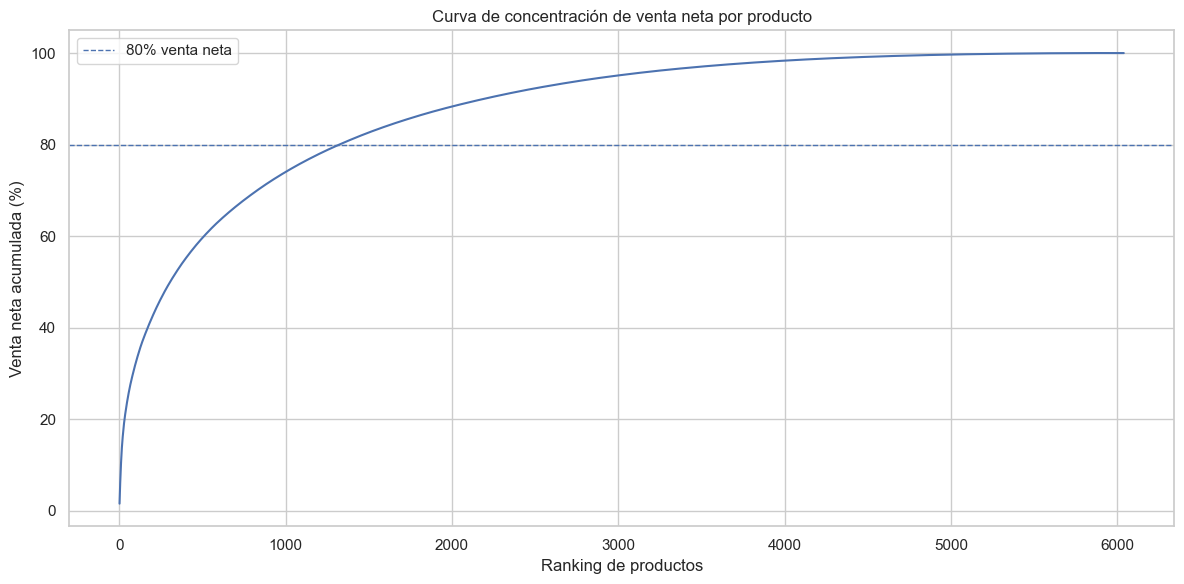

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\productos\pareto_productos_venta_neta.png


In [20]:
# ===============================
# Curva de Pareto de productos
# ===============================

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=productos_pareto,
    x="rank_producto",
    y="participacion_acumulada_pct"
)

plt.axhline(80, linestyle="--", linewidth=1, label="80% venta neta")
plt.title("Curva de concentración de venta neta por producto")
plt.xlabel("Ranking de productos")
plt.ylabel("Venta neta acumulada (%)")
plt.legend()
plt.tight_layout()

output_fig = PRODUCTOS_FIGURES_DIR / "pareto_productos_venta_neta.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [21]:
# ===============================
# Productos necesarios para explicar el 80% de la venta neta
# ===============================

productos_80 = productos_pareto[productos_pareto["participacion_acumulada_pct"] <= 80]

n_productos_80 = productos_80.shape[0]
total_productos = productos_pareto.shape[0]

pct_productos_80 = n_productos_80 / total_productos * 100

print(f"Total productos: {total_productos:,}")
print(f"Productos que explican hasta el 80% de la venta neta: {n_productos_80:,}")
print(f"Porcentaje de productos: {pct_productos_80:.2f}%")

productos_pareto.head(n_productos_80 + 5)

Total productos: 6,039
Productos que explican hasta el 80% de la venta neta: 1,321
Porcentaje de productos: 21.87%


,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,grupo_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_unidades_pct,ticket_promedio_producto,unidades_por_ticket,precio_unitario_neto_promedio,descuento_pct,promo_pct_lineas,registros_especiales_pct,venta_neta_acumulada,participacion_acumulada_pct,rank_producto,participacion_productos_pct
1513,1036246,7872,719,3,1,04010,10,7675,"2,007,463.00","48,506.00","1,958,957.00","10,799.00",812,143,7754,1.59,2.18,255.24,1.41,181.40,2.42,10.32,1.82,"1,958,957.00",1.59,1,0.02
1518,1036266,4699,697,3,1,04010,10,4397,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",901,146,4571,1.32,2.90,370.22,3.27,113.25,15.84,19.17,3.11,"3,586,835.00",2.91,2,0.03
4657,1331944,2142,569,3,1,04010,10,2117,"1,380,941.00","11,793.00","1,369,148.00","3,143.00",96,5,2137,1.11,0.63,646.74,1.48,435.62,0.85,4.48,0.23,"4,955,983.00",4.02,3,0.05
4936,1338873,8419,701,3,1,04010,10,8064,"1,338,612.00","26,871.00","1,311,741.00","13,508.00",1279,33,8387,1.06,2.73,162.67,1.68,97.11,2.01,15.19,0.39,"6,267,724.00",5.09,4,0.07
3166,1246431,842,79,3,1,08029,11,627,"1,603,593.00","340,519.00","1,263,074.00","1,606.00",613,133,709,1.03,0.32,"2,014.47",2.56,786.47,21.23,72.80,15.80,"7,530,798.00",6.11,5,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3693,1283321,140,128,3,1,08029,11,138,"20,451.00",834.00,"19,617.00",141.00,29,1,139,0.02,0.03,142.15,1.02,139.13,4.08,20.71,0.71,"98,567,524.00",80.01,1322,21.89
5324,1350337,15,13,1,1,04010,10,15,"19,605.00",0.00,"19,605.00",16.00,0,0,15,0.02,0.00,"1,307.00",1.07,"1,225.31",0.00,0.00,0.00,"98,587,129.00",80.03,1323,21.91
1915,1124546,22,22,3,1,08042,11,22,"19,931.00",355.00,"19,576.00",22.00,2,0,22,0.02,0.00,889.82,1.00,889.82,1.78,9.09,0.00,"98,606,705.00",80.04,1324,21.92
4009,1301235,12,12,3,1,08061,11,12,"21,247.00","1,673.00","19,574.00",14.00,6,0,12,0.02,0.00,"1,631.17",1.17,"1,398.14",7.87,50.00,0.00,"98,626,279.00",80.06,1325,21.94


In [22]:
# ===============================
# Clasificación ABC de productos
# ===============================

def clasificar_abc(pct_acumulado):
    if pct_acumulado <= 80:
        return "A"
    elif pct_acumulado <= 95:
        return "B"
    else:
        return "C"

productos_pareto["CLASE_ABC"] = productos_pareto["participacion_acumulada_pct"].apply(clasificar_abc)

resumen_abc = (
    productos_pareto.groupby("CLASE_ABC")
    .agg(
        productos=("PLU_SAP", "count"),
        venta_neta=("venta_neta", "sum"),
        unidades=("unidades", "sum"),
        tickets=("tickets", "sum")
    )
    .reset_index()
)

resumen_abc["productos_pct"] = resumen_abc["productos"] / resumen_abc["productos"].sum() * 100
resumen_abc["venta_neta_pct"] = resumen_abc["venta_neta"] / resumen_abc["venta_neta"].sum() * 100
resumen_abc["unidades_pct"] = resumen_abc["unidades"] / resumen_abc["unidades"].sum() * 100

resumen_abc

,CLASE_ABC,productos,venta_neta,unidades,tickets,productos_pct,venta_neta_pct,unidades_pct
0,A,1321,"98,547,907.00","381,529.92",285009,21.87,80.00,77.08
1,B,1653,"18,481,548.00","76,637.42",73271,27.37,15.00,15.48
2,C,3065,"6,162,907.00","36,805.89",32166,50.75,5.00,7.44


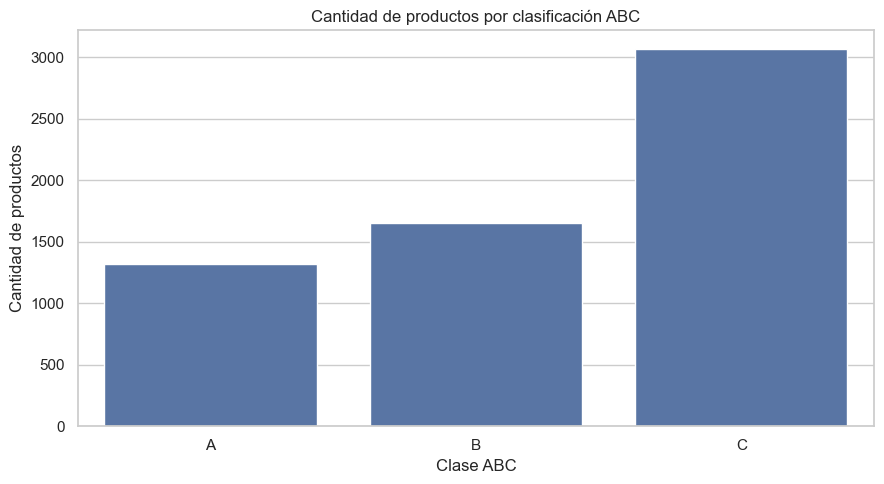

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\productos\productos_clasificacion_abc.png


In [23]:
# ===============================
# Distribución ABC de productos
# ===============================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=resumen_abc,
    x="CLASE_ABC",
    y="productos"
)

plt.title("Cantidad de productos por clasificación ABC")
plt.xlabel("Clase ABC")
plt.ylabel("Cantidad de productos")
plt.tight_layout()

output_fig = PRODUCTOS_FIGURES_DIR / "productos_clasificacion_abc.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

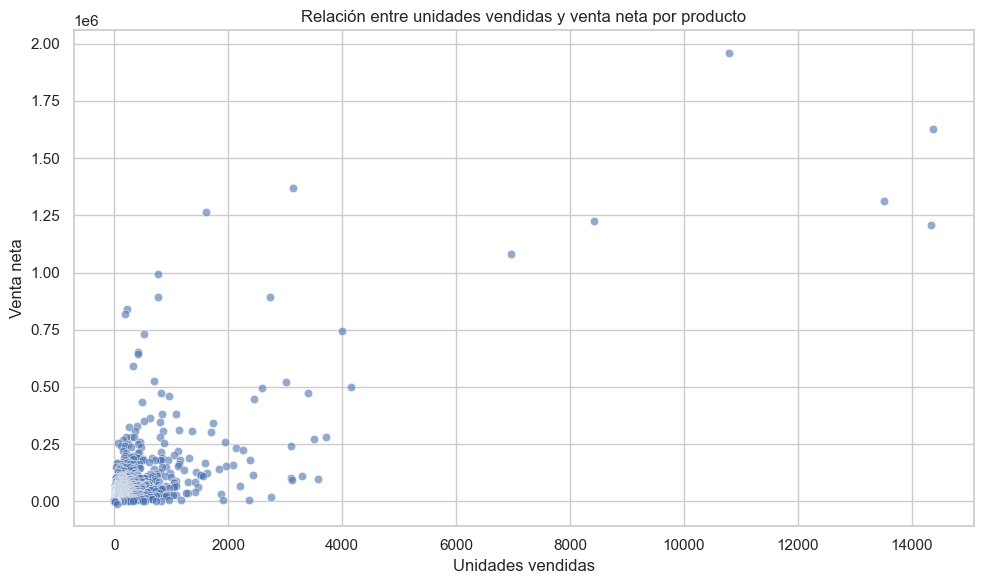

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\productos\venta_neta_vs_unidades_producto.png


In [24]:
# ===============================
# Relación venta neta vs unidades por producto
# ===============================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=resumen_productos,
    x="unidades",
    y="venta_neta",
    alpha=0.6
)

plt.title("Relación entre unidades vendidas y venta neta por producto")
plt.xlabel("Unidades vendidas")
plt.ylabel("Venta neta")
plt.tight_layout()

output_fig = PRODUCTOS_FIGURES_DIR / "venta_neta_vs_unidades_producto.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

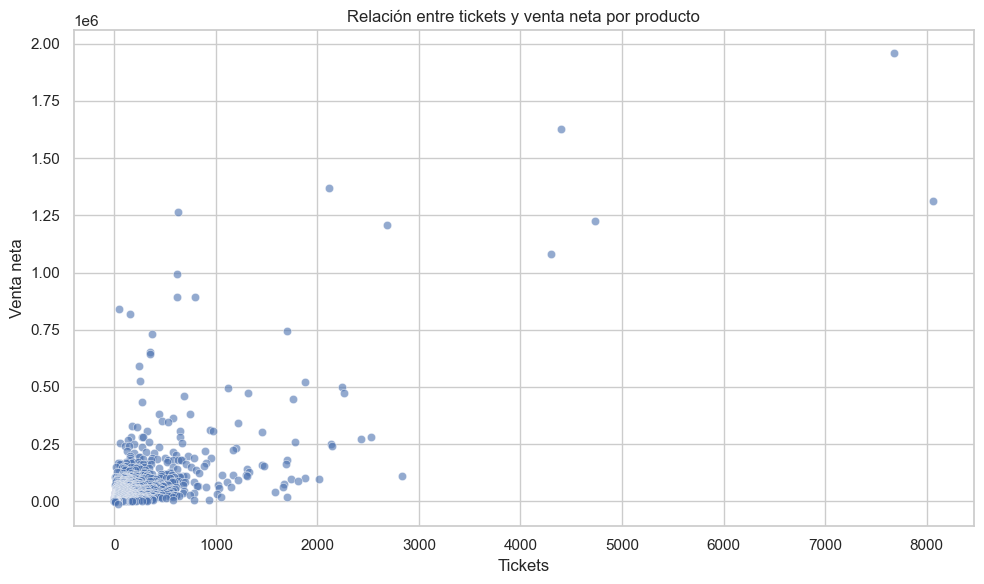

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\productos\venta_neta_vs_tickets_producto.png


In [25]:
# ===============================
# Relación venta neta vs tickets por producto
# ===============================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=resumen_productos,
    x="tickets",
    y="venta_neta",
    alpha=0.6
)

plt.title("Relación entre tickets y venta neta por producto")
plt.xlabel("Tickets")
plt.ylabel("Venta neta")
plt.tight_layout()

output_fig = PRODUCTOS_FIGURES_DIR / "venta_neta_vs_tickets_producto.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [26]:
# ===============================
# Productos de alto valor y baja frecuencia
# ===============================

q75_venta = resumen_productos["venta_neta"].quantile(0.75)
q25_tickets = resumen_productos["tickets"].quantile(0.25)

productos_alto_valor_baja_frecuencia = (
    resumen_productos[
        (resumen_productos["venta_neta"] >= q75_venta) &
        (resumen_productos["tickets"] <= q25_tickets)
    ]
    .sort_values("venta_neta", ascending=False)
)

print(f"Productos de alto valor y baja frecuencia: {len(productos_alto_valor_baja_frecuencia):,}")

productos_alto_valor_baja_frecuencia.head(30)

Productos de alto valor y baja frecuencia: 3


,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,grupo_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_unidades_pct,ticket_promedio_producto,unidades_por_ticket,precio_unitario_neto_promedio,descuento_pct,promo_pct_lineas,registros_especiales_pct
4564,1328019,2,2,1,1,08042,11,2,"119,234.00","11,980.00","107,254.00",23.00,1,0,2,0.09,0.00,"53,627.00",11.50,"4,663.22",10.05,50.00,0.00
4177,1314228,2,2,1,1,04010,10,2,"26,389.00",0.00,"26,389.00",3.00,0,0,2,0.02,0.00,"13,194.50",1.50,"8,796.33",0.00,0.00,0.00
2402,1166247,2,2,1,1,04010,10,2,"18,700.00",0.00,"18,700.00",2.00,0,0,2,0.02,0.00,"9,350.00",1.00,"9,350.00",0.00,0.00,0.00


In [27]:
# ===============================
# Productos frecuentes pero de bajo valor
# ===============================

q75_tickets = resumen_productos["tickets"].quantile(0.75)
q25_venta = resumen_productos["venta_neta"].quantile(0.25)

productos_frecuentes_bajo_valor = (
    resumen_productos[
        (resumen_productos["tickets"] >= q75_tickets) &
        (resumen_productos["venta_neta"] <= q25_venta)
    ]
    .sort_values("tickets", ascending=False)
)

print(f"Productos frecuentes pero de bajo valor: {len(productos_frecuentes_bajo_valor):,}")

productos_frecuentes_bajo_valor.head(30)

Productos frecuentes pero de bajo valor: 5


,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,grupo_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_unidades_pct,ticket_promedio_producto,unidades_por_ticket,precio_unitario_neto_promedio,descuento_pct,promo_pct_lineas,registros_especiales_pct
4571,1328254,74,64,2,1,08029,11,72,762.00,14.00,748.00,6.78,7,2,72,0.00,0.00,10.39,0.09,110.32,1.84,9.46,2.70
866,1016828,55,49,2,1,08042,11,55,"1,081.00",45.00,"1,036.00",327.00,8,0,55,0.00,0.07,18.84,5.95,3.17,4.16,14.55,0.00
4822,1335242,50,46,1,1,08042,11,50,"1,249.00",3.00,"1,246.00",64.00,1,0,50,0.00,0.01,24.92,1.28,19.47,0.24,2.00,0.00
1711,1113450,50,41,2,1,08042,11,49,"1,164.00",20.00,"1,144.00",70.00,6,1,49,0.00,0.01,23.35,1.43,16.34,1.72,12.00,2.00
1036,1018389,46,46,3,1,08042,11,46,"1,126.00",13.00,"1,113.00",52.00,5,0,46,0.00,0.01,24.20,1.13,21.40,1.15,10.87,0.00


In [28]:
# ===============================
# Productos con alta dependencia promocional
# ===============================

productos_alta_promo = (
    resumen_productos[
        (resumen_productos["filas"] >= resumen_productos["filas"].quantile(0.50)) &
        (resumen_productos["promo_pct_lineas"] >= resumen_productos["promo_pct_lineas"].quantile(0.75))
    ]
    .sort_values("promo_pct_lineas", ascending=False)
)

print(f"Productos con alta dependencia promocional: {len(productos_alta_promo):,}")

productos_alta_promo.head(30)

Productos con alta dependencia promocional: 753


,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,grupo_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_unidades_pct,ticket_promedio_producto,unidades_por_ticket,precio_unitario_neto_promedio,descuento_pct,promo_pct_lineas,registros_especiales_pct
5018,1341191,42,32,1,1,08042,11,41,"7,477.00","17,473.00","-9,996.00",42.00,41,41,1,-0.01,0.01,-243.80,1.02,-238.00,233.69,97.62,97.62
2760,1206212,26,17,2,1,08062,11,26,"22,570.00","12,355.00","10,215.00",26.00,25,0,26,0.01,0.01,392.88,1.00,392.88,54.74,96.15,0.00
5482,1357926,22,17,3,1,08062,11,22,"7,667.00","4,457.00","3,210.00",22.00,21,1,21,0.00,0.00,145.91,1.00,145.91,58.13,95.45,4.55
1528,1037654,22,13,1,1,08062,11,22,"37,541.00","20,208.00","17,333.00",24.00,21,0,22,0.01,0.00,787.86,1.09,722.21,53.83,95.45,0.00
1560,1041556,18,14,1,1,08062,11,18,"21,368.00","11,760.00","9,608.00",18.00,17,0,18,0.01,0.00,533.78,1.00,533.78,55.04,94.44,0.00
3928,1293785,17,10,2,1,08062,11,17,"16,409.00","9,371.00","7,038.00",17.00,16,0,17,0.01,0.00,414.00,1.00,414.00,57.11,94.12,0.00
3716,1284265,16,11,2,1,08062,11,16,"24,927.00","13,437.00","11,490.00",16.00,15,0,16,0.01,0.00,718.12,1.00,718.12,53.91,93.75,0.00
4552,1327826,16,13,2,1,08042,11,16,"8,692.00","1,912.00","6,780.00",16.00,15,0,16,0.01,0.00,423.75,1.00,423.75,22.00,93.75,0.00
4344,1320430,16,14,2,1,04010,10,15,"6,381.00","3,668.00","2,713.00",17.00,15,1,15,0.00,0.00,180.87,1.13,159.59,57.48,93.75,6.25
3916,1293328,16,14,1,1,08042,11,15,"33,364.00","7,052.00","26,312.00",16.00,15,0,16,0.02,0.00,"1,754.13",1.07,"1,644.50",21.14,93.75,0.00


In [29]:
# ===============================
# Categoría principal de productos top por venta
# ===============================

top_productos_con_categoria = top_productos_venta[[
    "PLU_SAP",
    "categoria_principal",
    "grupo_principal",
    "venta_neta",
    "unidades",
    "tickets",
    "promo_pct_lineas",
    "descuento_pct"
]].copy()

top_productos_con_categoria

,PLU_SAP,categoria_principal,grupo_principal,venta_neta,unidades,tickets,promo_pct_lineas,descuento_pct
1513,1036246,04010,10,"1,958,957.00","10,799.00",7675,10.32,2.42
1518,1036266,04010,10,"1,627,878.00","14,374.00",4397,19.17,15.84
4657,1331944,04010,10,"1,369,148.00","3,143.00",2117,4.48,0.85
4936,1338873,04010,10,"1,311,741.00","13,508.00",8064,15.19,2.01
3166,1246431,08029,11,"1,263,074.00","1,606.00",627,72.80,21.23
1515,1036252,04010,10,"1,225,589.00","8,419.00",4735,18.23,6.79
1516,1036253,04010,10,"1,208,016.00","14,342.00",2682,21.28,27.46
4155,1313279,04010,10,"1,082,770.00","6,971.00",4299,21.01,5.49
1324,1023807,04010,10,"995,053.00",771.00,615,36.65,10.65
1556,1041245,04010,10,"894,911.00","2,724.00",793,8.59,8.77


In [30]:
# ===============================
# Pareto por categoría
# ===============================

pareto_categoria_producto = []

for categoria in sorted(df["CATEG"].dropna().unique()):
    temp = (
        df[df["CATEG"] == categoria]
        .groupby("PLU_SAP")
        .agg(
            venta_neta=("VENTA_NETA", "sum"),
            unidades=("CANT", "sum"),
            tickets=("TICKET_ID", "nunique")
        )
        .reset_index()
        .sort_values("venta_neta", ascending=False)
    )
    
    temp["venta_acumulada"] = temp["venta_neta"].cumsum()
    total_venta_cat = temp["venta_neta"].sum()
    
    temp["participacion_acumulada_pct"] = np.where(
        total_venta_cat != 0,
        temp["venta_acumulada"] / total_venta_cat * 100,
        np.nan
    )
    
    temp["rank_producto_categoria"] = np.arange(1, len(temp) + 1)
    temp["CATEG"] = categoria
    
    pareto_categoria_producto.append(temp)

pareto_categoria_producto = pd.concat(pareto_categoria_producto, ignore_index=True)

pareto_categoria_producto.head()

,PLU_SAP,venta_neta,unidades,tickets,venta_acumulada,participacion_acumulada_pct,rank_producto_categoria,CATEG
0,1036246,"1,958,957.00","10,799.00",7675,"1,958,957.00",3.64,1,04010
1,1036266,"1,627,878.00","14,374.00",4397,"3,586,835.00",6.67,2,04010
2,1331944,"1,369,148.00","3,143.00",2117,"4,955,983.00",9.22,3,04010
3,1338873,"1,311,741.00","13,508.00",8064,"6,267,724.00",11.65,4,04010
4,1036252,"1,225,589.00","8,419.00",4735,"7,493,313.00",13.93,5,04010


In [31]:
# ===============================
# Productos necesarios para explicar 80% por categoría
# ===============================

productos_80_categoria = (
    pareto_categoria_producto[pareto_categoria_producto["participacion_acumulada_pct"] <= 80]
    .groupby("CATEG")
    .agg(productos_hasta_80=("PLU_SAP", "count"))
    .reset_index()
)

total_productos_categoria = (
    df.groupby("CATEG")["PLU_SAP"]
    .nunique()
    .reset_index(name="productos_totales")
)

productos_80_categoria = productos_80_categoria.merge(
    total_productos_categoria,
    on="CATEG",
    how="left"
)

productos_80_categoria["productos_hasta_80_pct"] = (
    productos_80_categoria["productos_hasta_80"] /
    productos_80_categoria["productos_totales"] * 100
)

productos_80_categoria

,CATEG,productos_hasta_80,productos_totales,productos_hasta_80_pct
0,04010,228,1173,19.44
1,04019,1,2,50.00
2,08029,318,1391,22.86
3,08042,478,1748,27.35
4,08061,242,804,30.10
5,08062,228,666,34.23
6,08067,62,255,24.31


In [32]:
# ===============================
# Venta por categoría y PDV
# ===============================

categoria_pdv = (
    df.groupby(["PDV", "CATEG"])
    .agg(
        filas=("NroReg", "count"),
        productos=("PLU_SAP", "nunique"),
        tickets=("TICKET_ID", "nunique"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

categoria_pdv["promo_pct_lineas"] = np.where(
    categoria_pdv["filas"] > 0,
    categoria_pdv["lineas_promo"] / categoria_pdv["filas"] * 100,
    np.nan
)

total_venta_pdv = categoria_pdv.groupby("PDV")["venta_neta"].transform("sum")

categoria_pdv["participacion_dentro_pdv_pct"] = np.where(
    total_venta_pdv != 0,
    categoria_pdv["venta_neta"] / total_venta_pdv * 100,
    np.nan
)

categoria_pdv.sort_values(["PDV", "venta_neta"], ascending=[True, False])

,PDV,CATEG,filas,productos,tickets,venta_neta,unidades,lineas_promo,promo_pct_lineas,participacion_dentro_pdv_pct
0,1255,04010,49983,592,39004,"15,838,378.00","92,368.00",10203,20.41,48.37
2,1255,08029,42548,1089,32185,"7,021,355.00","35,378.64",12016,28.24,21.44
3,1255,08042,17664,931,14214,"5,332,248.00","17,133.88",4896,27.72,16.29
4,1255,08061,18208,600,14628,"2,633,296.00","16,444.62",3989,21.91,8.04
5,1255,08062,3458,371,2756,"1,480,929.00","3,236.05",2024,58.53,4.52
6,1255,08067,576,151,203,"420,306.00",800.36,1,0.17,1.28
1,1255,04019,190,2,189,"15,656.00",219.00,0,0.00,0.05
7,1311,04010,70024,943,53286,"26,877,501.00","89,371.00",14031,20.04,37.40
10,1311,08042,30653,1555,23024,"20,615,820.00","38,661.35",10633,34.69,28.69
9,1311,08029,66017,1199,45322,"13,882,169.00","66,504.85",21590,32.70,19.32


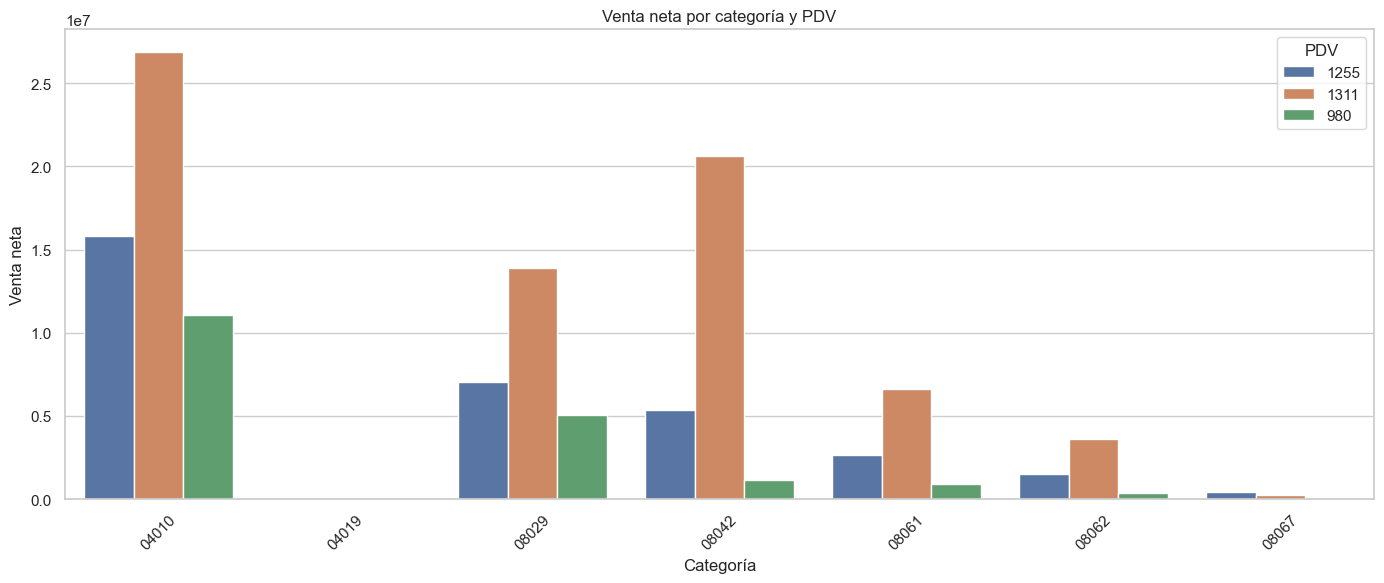

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\categorias\venta_neta_categoria_pdv.png


In [33]:
# ===============================
# Gráfico categoría por PDV
# ===============================

plt.figure(figsize=(14, 6))

sns.barplot(
    data=categoria_pdv,
    x="CATEG",
    y="venta_neta",
    hue="PDV"
)

plt.title("Venta neta por categoría y PDV")
plt.xlabel("Categoría")
plt.ylabel("Venta neta")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = CATEGORIAS_FIGURES_DIR / "venta_neta_categoria_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

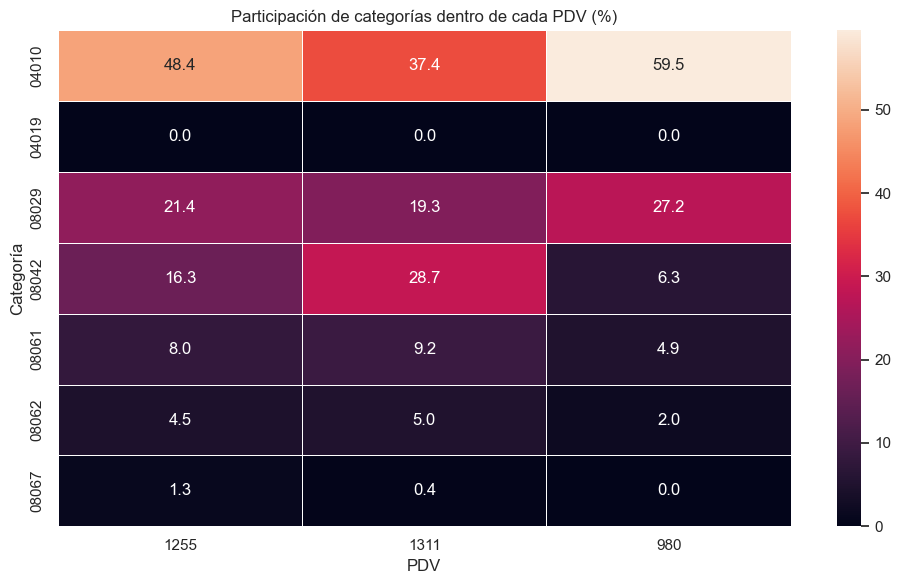

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\categorias\heatmap_categoria_pdv_participacion.png


In [34]:
# ===============================
# Heatmap participación categoría dentro de cada PDV
# ===============================

tabla_heatmap_categoria_pdv = categoria_pdv.pivot_table(
    index="CATEG",
    columns="PDV",
    values="participacion_dentro_pdv_pct",
    fill_value=0
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    tabla_heatmap_categoria_pdv,
    annot=True,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Participación de categorías dentro de cada PDV (%)")
plt.xlabel("PDV")
plt.ylabel("Categoría")
plt.tight_layout()

output_fig = CATEGORIAS_FIGURES_DIR / "heatmap_categoria_pdv_participacion.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [35]:
# ===============================
# Evolución mensual por categoría
# ===============================

categoria_mensual = (
    df.groupby(["ANIO", "MES", "CATEG"])
    .agg(
        filas=("NroReg", "count"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

categoria_mensual["FECHA_MES"] = pd.to_datetime(
    categoria_mensual["ANIO"].astype(str) + "-" +
    categoria_mensual["MES"].astype(str) + "-01"
)

categoria_mensual.head()

,ANIO,MES,CATEG,filas,venta_neta,unidades,tickets,productos,lineas_promo,FECHA_MES
0,2023,1,04010,6873,"2,245,771.00","10,310.00",5067,614,1564,2023-01-01
1,2023,1,04019,13,"1,240.00",18.00,13,2,0,2023-01-01
2,2023,1,08029,6085,"1,135,968.00","5,593.39",4478,822,1943,2023-01-01
3,2023,1,08042,2901,"1,339,053.00","3,254.71",2217,794,1122,2023-01-01
4,2023,1,08061,2679,"462,396.00","2,721.08",2050,490,742,2023-01-01


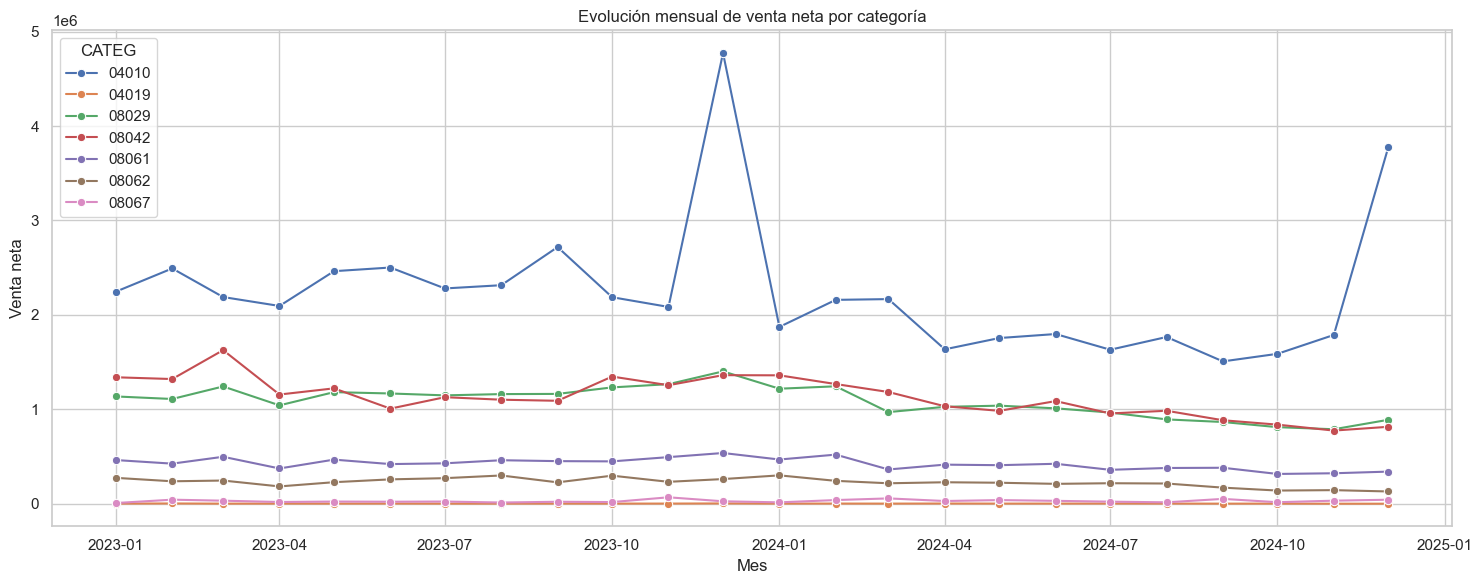

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\categorias\evolucion_mensual_categoria.png


In [36]:
# ===============================
# Gráfico evolución mensual por categoría
# ===============================

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=categoria_mensual,
    x="FECHA_MES",
    y="venta_neta",
    hue="CATEG",
    marker="o"
)

plt.title("Evolución mensual de venta neta por categoría")
plt.xlabel("Mes")
plt.ylabel("Venta neta")
plt.tight_layout()

output_fig = CATEGORIAS_FIGURES_DIR / "evolucion_mensual_categoria.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [37]:
# ===============================
# Productos con mayor cobertura temporal
# ===============================

top_productos_dias = (
    resumen_productos
    .sort_values("dias", ascending=False)
    .head(20)
    .copy()
)

top_productos_dias

,PLU_SAP,filas,dias,pdv,categorias,categoria_principal,grupo_principal,tickets,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_unidades_pct,ticket_promedio_producto,unidades_por_ticket,precio_unitario_neto_promedio,descuento_pct,promo_pct_lineas,registros_especiales_pct
1513,1036246,7872,719,3,1,04010,10,7675,"2,007,463.00","48,506.00","1,958,957.00","10,799.00",812,143,7754,1.59,2.18,255.24,1.41,181.40,2.42,10.32,1.82
1515,1036252,5075,708,3,1,04010,10,4735,"1,314,831.00","89,242.00","1,225,589.00","8,419.00",925,207,4886,0.99,1.70,258.84,1.78,145.57,6.79,18.23,4.08
4936,1338873,8419,701,3,1,04010,10,8064,"1,338,612.00","26,871.00","1,311,741.00","13,508.00",1279,33,8387,1.06,2.73,162.67,1.68,97.11,2.01,15.19,0.39
1518,1036266,4699,697,3,1,04010,10,4397,"1,934,190.00","306,312.00","1,627,878.00","14,374.00",901,146,4571,1.32,2.90,370.22,3.27,113.25,15.84,19.17,3.11
1179,1019569,2950,697,3,1,08061,11,2835,"115,929.00","4,494.00","111,435.00","3,300.00",562,20,2930,0.09,0.67,39.31,1.16,33.77,3.88,19.05,0.68
4155,1313279,4665,695,3,1,04010,10,4299,"1,145,699.00","62,929.00","1,082,770.00","6,971.00",980,126,4545,0.88,1.41,251.87,1.62,155.32,5.49,21.01,2.70
2207,1149608,2343,671,3,1,08029,11,2148,"254,258.00","13,056.00","241,202.00","3,102.00",539,42,2306,0.20,0.63,112.29,1.44,77.76,5.13,23.00,1.79
3674,1281570,2719,671,3,1,08029,11,2529,"292,731.00","12,453.00","280,278.00","3,721.00",592,30,2689,0.23,0.75,110.83,1.47,75.32,4.25,21.77,1.10
3994,1299851,2593,644,3,1,08029,11,2430,"281,449.00","10,803.00","270,646.00","3,507.00",535,39,2555,0.22,0.71,111.38,1.44,77.17,3.84,20.63,1.50
438,1012222,1831,633,3,1,08029,11,1781,"277,344.00","15,549.00","261,795.00","1,939.00",539,15,1816,0.21,0.39,146.99,1.09,135.02,5.61,29.44,0.82


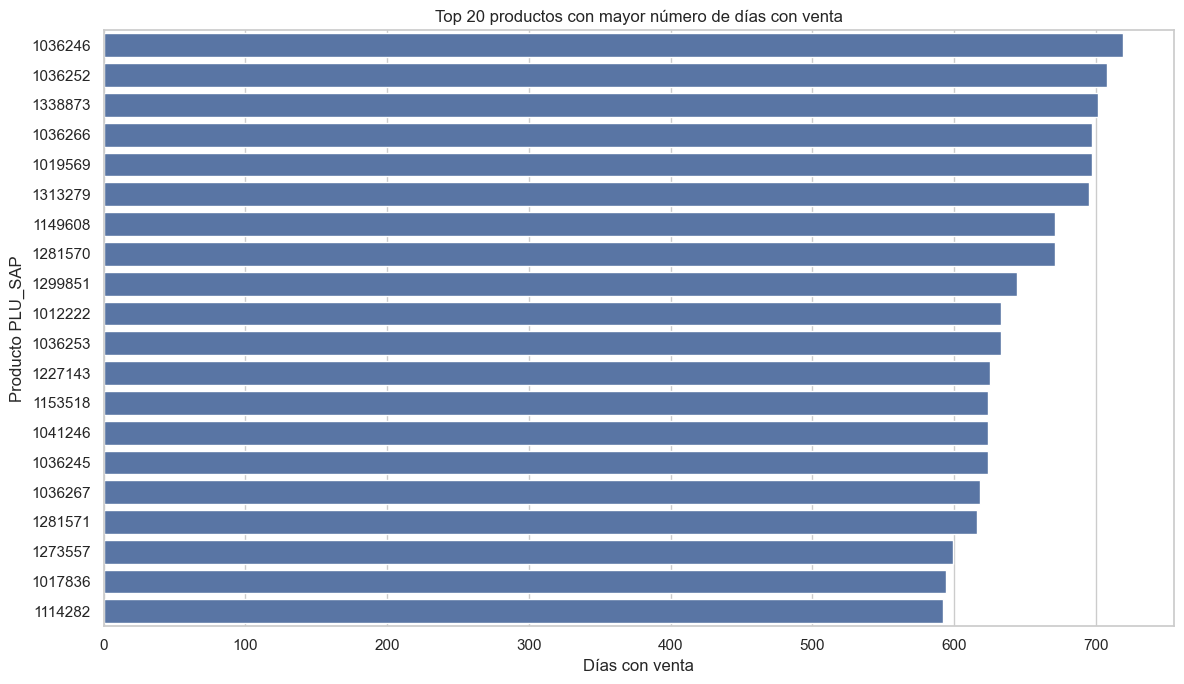

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\productos\top_20_productos_dias_venta.png


In [38]:
# ===============================
# Gráfico productos con más días de venta
# ===============================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_productos_dias,
    y="PLU_SAP",
    x="dias"
)

plt.title("Top 20 productos con mayor número de días con venta")
plt.xlabel("Días con venta")
plt.ylabel("Producto PLU_SAP")
plt.tight_layout()

output_fig = PRODUCTOS_FIGURES_DIR / "top_20_productos_dias_venta.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [39]:
# ===============================
# Variabilidad diaria de productos top
# ===============================

top_20_plu = top_productos_venta["PLU_SAP"].tolist()

ventas_diarias_producto_top = (
    df[df["PLU_SAP"].isin(top_20_plu)]
    .groupby(["FECHA", "PLU_SAP"])
    .agg(
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique")
    )
    .reset_index()
)

variabilidad_productos_top = (
    ventas_diarias_producto_top.groupby("PLU_SAP")
    .agg(
        media_venta_diaria=("venta_neta", "mean"),
        mediana_venta_diaria=("venta_neta", "median"),
        std_venta_diaria=("venta_neta", "std"),
        min_venta_diaria=("venta_neta", "min"),
        max_venta_diaria=("venta_neta", "max"),
        dias_con_venta=("FECHA", "nunique")
    )
    .reset_index()
)

variabilidad_productos_top["coef_variacion_venta"] = np.where(
    variabilidad_productos_top["media_venta_diaria"] != 0,
    variabilidad_productos_top["std_venta_diaria"] / variabilidad_productos_top["media_venta_diaria"],
    np.nan
)

variabilidad_productos_top.sort_values("coef_variacion_venta", ascending=False)

,PLU_SAP,media_venta_diaria,mediana_venta_diaria,std_venta_diaria,min_venta_diaria,max_venta_diaria,dias_con_venta,coef_variacion_venta
10,1041246,"1,196.31",534.00,"7,179.64",0.00,"133,900.00",624,6.00
9,1041245,"2,182.71",803.00,"12,664.72",0.00,"206,115.00",410,5.80
7,1036253,"1,908.40",666.00,"10,965.42","-16,473.00","199,584.00",633,5.75
8,1036266,"2,335.55","1,086.00","11,701.65",2.00,"257,260.00",697,5.01
12,1246431,"15,988.28","1,229.00","26,254.22",492.00,"84,071.00",79,1.64
0,1019790,"23,395.42","16,995.00","33,154.28","2,373.00","195,457.00",36,1.42
19,1342490,908.65,597.00,"1,152.41",114.00,"16,125.00",576,1.27
17,1331944,"2,406.24","1,390.00","2,960.54",386.00,"32,573.00",569,1.23
15,1287168,"3,472.94","1,741.00","3,803.37",647.00,"30,476.00",210,1.10
13,1281459,"14,235.86","5,751.00","15,270.73",479.00,"40,256.00",37,1.07


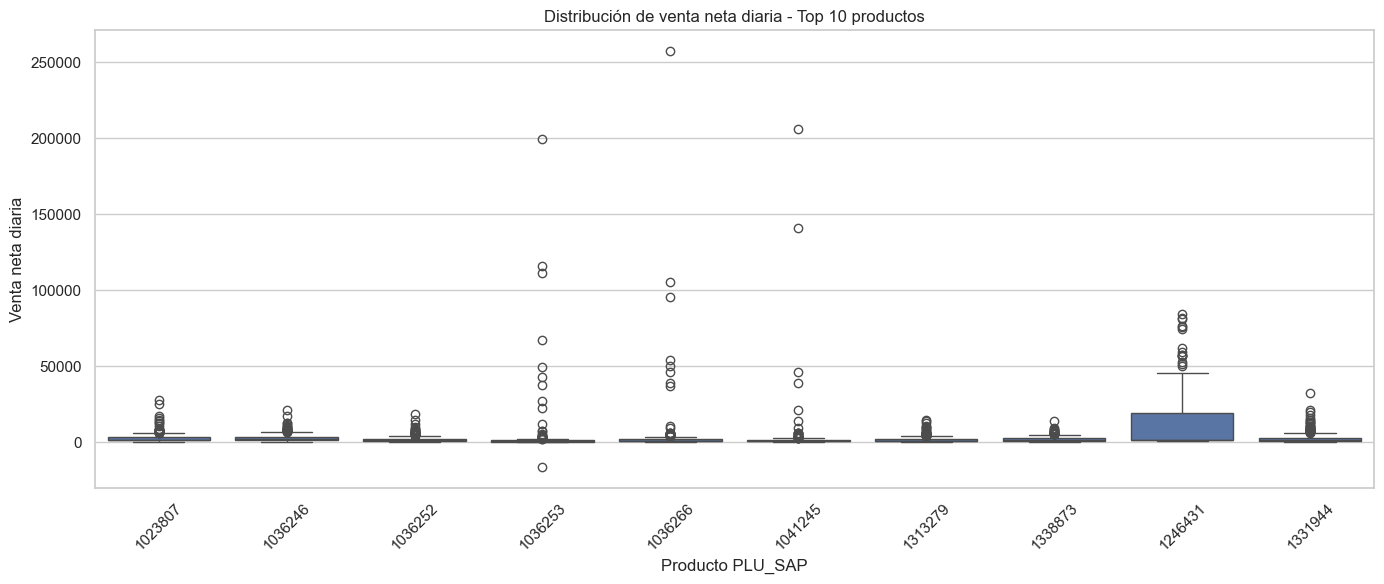

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\productos\boxplot_venta_diaria_top_10_productos.png


In [40]:
# ===============================
# Boxplot venta diaria productos top 10
# ===============================

top_10_plu = top_productos_venta["PLU_SAP"].head(10).tolist()

ventas_diarias_producto_top_10 = ventas_diarias_producto_top[
    ventas_diarias_producto_top["PLU_SAP"].isin(top_10_plu)
].copy()

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=ventas_diarias_producto_top_10,
    x="PLU_SAP",
    y="venta_neta"
)

plt.title("Distribución de venta neta diaria - Top 10 productos")
plt.xlabel("Producto PLU_SAP")
plt.ylabel("Venta neta diaria")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = PRODUCTOS_FIGURES_DIR / "boxplot_venta_diaria_top_10_productos.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

In [41]:
# ===============================
# Calidad de datos por producto
# ===============================

calidad_productos = (
    df.groupby("PLU_SAP")
    .agg(
        filas=("NroReg", "count"),
        categoria_principal=("CATEG", lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum"),
        registros_validos_basicos=("REGISTRO_VALIDO_BASICO", "sum")
    )
    .reset_index()
)

calidad_productos["registros_especiales_pct"] = np.where(
    calidad_productos["filas"] > 0,
    calidad_productos["registros_especiales"] / calidad_productos["filas"] * 100,
    np.nan
)

calidad_productos = calidad_productos.sort_values(
    ["registros_especiales_pct", "filas"],
    ascending=[False, False]
)

calidad_productos.head(30)

,PLU_SAP,filas,categoria_principal,venta_neta,unidades,registros_especiales,registros_validos_basicos,registros_especiales_pct
5799,1373003,28,08029,"3,038.00",0.00,28,0,100.00
5793,1372523,16,08029,"4,015.00",0.00,16,0,100.00
5794,1372649,16,08062,"8,574.00",0.00,16,0,100.00
5754,1371192,13,08029,"2,324.00",0.00,13,0,100.00
5773,1371942,12,08061,"1,070.00",0.00,12,0,100.00
5819,1374643,12,08042,"11,286.00",0.00,12,0,100.00
5817,1374554,10,08062,"8,043.00",0.00,10,0,100.00
5818,1374555,7,08062,"1,780.00",0.00,7,0,100.00
84,1008762,6,08061,0.00,0.00,6,0,100.00
5796,1372652,6,08062,"12,268.00",0.00,6,0,100.00


In [42]:
# ===============================
# Resumen ejecutivo de productos
# ===============================

resumen_ejecutivo_productos = pd.DataFrame({
    "metrica": [
        "Productos únicos",
        "Categorías únicas",
        "Producto con mayor venta neta",
        "Mayor venta neta de un producto",
        "Producto con más unidades",
        "Mayor cantidad de unidades",
        "Producto con más tickets",
        "Mayor cantidad de tickets",
        "Productos necesarios para explicar 80% de venta",
        "Porcentaje de productos que explican 80% de venta",
        "Venta neta total",
        "Unidades totales"
    ],
    "valor": [
        resumen_productos["PLU_SAP"].nunique(),
        resumen_categorias["CATEG"].nunique(),
        top_productos_venta.iloc[0]["PLU_SAP"],
        top_productos_venta.iloc[0]["venta_neta"],
        top_productos_unidades.iloc[0]["PLU_SAP"],
        top_productos_unidades.iloc[0]["unidades"],
        top_productos_tickets.iloc[0]["PLU_SAP"],
        top_productos_tickets.iloc[0]["tickets"],
        n_productos_80,
        pct_productos_80,
        resumen_productos["venta_neta"].sum(),
        resumen_productos["unidades"].sum()
    ]
})

resumen_ejecutivo_productos

,metrica,valor
0,Productos únicos,6039
1,Categorías únicas,7
2,Producto con mayor venta neta,1036246
3,Mayor venta neta de un producto,"1,958,957.00"
4,Producto con más unidades,1036266
5,Mayor cantidad de unidades,"14,374.00"
6,Producto con más tickets,1338873
7,Mayor cantidad de tickets,8064
8,Productos necesarios para explicar 80% de venta,1321
9,Porcentaje de productos que explican 80% de venta,21.87


In [43]:
# ===============================
# Exportar tablas del análisis
# ===============================

output_excel = TABLES_DIR / "05_analisis_categorias_productos.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    resumen_categorias.to_excel(writer, sheet_name="resumen_categorias", index=False)
    resumen_productos.to_excel(writer, sheet_name="resumen_productos", index=False)
    top_productos_venta.to_excel(writer, sheet_name="top_productos_venta", index=False)
    top_productos_unidades.to_excel(writer, sheet_name="top_productos_unidades", index=False)
    top_productos_tickets.to_excel(writer, sheet_name="top_productos_tickets", index=False)
    top_productos_descuento.to_excel(writer, sheet_name="top_productos_descuento", index=False)
    productos_pareto.to_excel(writer, sheet_name="pareto_productos", index=False)
    resumen_abc.to_excel(writer, sheet_name="resumen_abc", index=False)
    productos_80_categoria.to_excel(writer, sheet_name="productos_80_categoria", index=False)
    productos_alto_valor_baja_frecuencia.to_excel(writer, sheet_name="alto_valor_baja_freq", index=False)
    productos_frecuentes_bajo_valor.to_excel(writer, sheet_name="frecuentes_bajo_valor", index=False)
    productos_alta_promo.to_excel(writer, sheet_name="alta_promo", index=False)
    categoria_pdv.to_excel(writer, sheet_name="categoria_pdv", index=False)
    categoria_mensual.to_excel(writer, sheet_name="categoria_mensual", index=False)
    variabilidad_productos_top.to_excel(writer, sheet_name="variabilidad_top", index=False)
    calidad_productos.to_excel(writer, sheet_name="calidad_productos", index=False)
    resumen_ejecutivo_productos.to_excel(writer, sheet_name="resumen_ejecutivo", index=False)

print(f"Archivo Excel exportado correctamente en: {output_excel}")

Archivo Excel exportado correctamente en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\tables\05_analisis_categorias_productos.xlsx


## Conclusiones del análisis de categorías y productos

A partir del análisis de categorías y productos, se identifican varios elementos importantes para entender la estructura comercial de la base:

1. Las ventas no se distribuyen de manera uniforme entre categorías. Algunas categorías concentran una proporción mucho mayor de la venta neta total.

2. La cantidad de productos por categoría no necesariamente implica mayor venta. Algunas categorías pueden tener muchos productos, pero menor participación en venta neta.

3. El análisis de productos muestra que la venta está concentrada en un subconjunto reducido de SKUs. Esto se evidencia en la curva de Pareto y en la clasificación ABC.

4. La clasificación ABC permite separar los productos en tres grupos:
   - Productos A: productos críticos que explican la mayor parte de la venta.
   - Productos B: productos de importancia intermedia.
   - Productos C: productos de baja participación individual.

5. El análisis de productos por venta neta, unidades y tickets permite diferenciar distintos tipos de productos:
   - Productos de alto valor.
   - Productos de alta rotación.
   - Productos muy frecuentes.
   - Productos con alto descuento.
   - Productos con alta dependencia promocional.

6. Los productos de alto valor y baja frecuencia deben revisarse con cuidado, ya que pueden representar ventas importantes pero poco recurrentes.

7. Los productos frecuentes pero de bajo valor pueden ser relevantes para explicar tráfico, hábitos de compra o composición del ticket.

8. La comparación de categorías entre PDV muestra si las tiendas tienen una mezcla comercial similar o si cada una depende de categorías diferentes.

9. La evolución mensual por categoría permite identificar si algunas categorías presentan patrones temporales más fuertes que otras.

10. Para un futuro modelo de predicción, las variables de categoría y producto serán fundamentales. Sin embargo, debido a la alta cantidad de productos, puede ser necesario evaluar estrategias de agregación, selección de productos principales o clasificación ABC antes de modelar.